In [11]:
from configilm import util
#util.MESSAGE_LEVEL = util.MessageLevel.INFO  # use INFO to see all messages

from configilm.extra.DataSets import BENv2_DataSet
from configilm.extra.DataModules import BENv2_DataModule
import yaml
from torchvision import transforms 
import torchvision

In [2]:
## Import modules 
from src.utils.utils import load_config
from src.data.loader import bigearthnet_loader, bigearthnet_DataModule

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
config_path = "src/config/config.yaml"
config_dataset = load_config(config_path)

In [5]:
config_dataset["datasets"]

{'lmdb': '/root/storage_ds/encoder_lmdb',
 'metadata_parquet': '/root/storage_ds/metadata.parquet',
 'metadata_snow_cloud_parquet': '/root/storage_ds/metadata_snow_cloud.parquet'}

In [21]:
import os
os.path.isdir("/root/storage_ds/encoder_lmdb")

True

In [23]:
## Create a LoaderDataset torch instance 
ds = bigearthnet_loader(
    path_dataset_lmdb=config_dataset["datasets"]["lmdb"],
    path_metadata_parquet=config_dataset["datasets"]["metadata_parquet"],
    path_metadata_snow_cloud_parquet=config_dataset["datasets"]["metadata_snow_cloud_parquet"],
    train= True
)

[INFO]    Loading BEN data for None...
[INFO]        480038 patches indexed
[INFO]        480038 pre-filtered patches indexed
[INFO]        480038 filtered patches indexed
[INFO]    Merged metadata with snow/cloud metadata
[INFO]    Loaded 549488 labels
[INFO]    Loaded 549488 keys
[INFO]    Loaded mapping created


'/root/storage_ds/encoder_lmdb'

In [19]:
## Create a DataModule instance, very common and present at lightning-torch
dm = bigearthnet_DataModule(
    path_dataset_lmdb=config_dataset["datasets"]["lmdb"],
    path_metadata_parquet=config_dataset["datasets"]["metadata_parquet"],
    path_metadata_snow_cloud_parquet=config_dataset["datasets"]["metadata_snow_cloud_parquet"],
    batch_size=4,
    shuffle=False,
    max_len=32,
    img_size=(10,120,120),        
    train_transforms = transforms.Compose([
                                transforms.Resize((224, 224))  # Direct resize to expected size
                                ]),
    eval_transforms = transforms.Compose([
                                    transforms.Resize((224, 224))  # Direct resize to expected size
                                ])
        )
       

[WARNING] Shuffle was set to False. This is not recommended for most configuration. Use shuffle=None (default) for recommended configuration.


In [20]:
dm.setup(stage="fit")

[INFO]    Loading BEN data for train...
[INFO]        237871 patches indexed
[INFO]        237871 pre-filtered patches indexed
[INFO]        32 filtered patches indexed
[INFO]    Merged metadata with snow/cloud metadata
[INFO]    Loaded 549488 labels
[INFO]    Loaded 549488 keys
[INFO]    Loaded mapping created
[INFO]    Loading BEN data for validation...
[INFO]        122342 patches indexed
[INFO]        122342 pre-filtered patches indexed
[INFO]        32 filtered patches indexed
[INFO]    Merged metadata with snow/cloud metadata
[INFO]    Loaded 549488 labels
[INFO]    Loaded 549488 keys
[INFO]    Loaded mapping created
[INFO]      Total training samples:       32  Total validation samples:       32


In [21]:
len(dm.train_dataloader())

8

In [22]:
for x_train, y_train in dm.train_dataloader():
    print(x_train.shape,y_train.shape)

[INFO]    Opening LMDB environment ...
[INFO]    Opening LMDB environment ...[INFO]    Opening LMDB environment ...

[INFO]    Opening LMDB environment ...
torch.Size([4, 10, 224, 224]) torch.Size([4, 19])
torch.Size([4, 10, 224, 224]) torch.Size([4, 19])
torch.Size([4, 10, 224, 224]) torch.Size([4, 19])
torch.Size([4, 10, 224, 224]) torch.Size([4, 19])
torch.Size([4, 10, 224, 224]) torch.Size([4, 19])
torch.Size([4, 10, 224, 224]) torch.Size([4, 19])
torch.Size([4, 10, 224, 224]) torch.Size([4, 19])
torch.Size([4, 10, 224, 224]) torch.Size([4, 19])


[INFO]    Opening LMDB environment ...[INFO]    Opening LMDB environment ...



TypeError: Invalid shape (454, 1810, 10) for image data

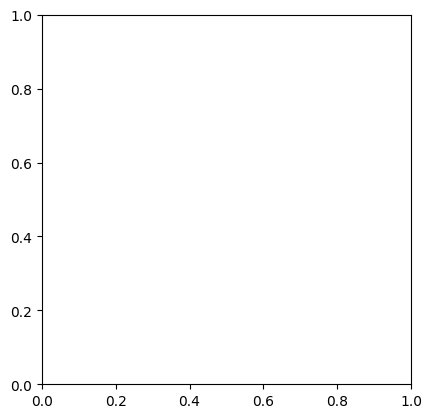

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(dm.train_dataloader())
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [16]:
len(dm.train_dataloader().dataset)

10

In [8]:
print(dm.train_ds)
print(dm.val_ds)
print(dm.test_ds)
dm.setup(stage="fit")
print(dm.train_ds)
print(dm.val_ds)
print(dm.test_ds)

None
None
None
[INFO]    Loading BEN data for train...
[INFO]        237871 patches indexed
[INFO]        237871 pre-filtered patches indexed
[INFO]        237871 filtered patches indexed
[INFO]    Merged metadata with snow/cloud metadata
[INFO]    Loaded 549488 labels
[INFO]    Loaded 549488 keys
[INFO]    Loaded mapping created
[INFO]    Loading BEN data for validation...
[INFO]        122342 patches indexed
[INFO]        122342 pre-filtered patches indexed
[INFO]        122342 filtered patches indexed
[INFO]    Merged metadata with snow/cloud metadata
[INFO]    Loaded 549488 labels
[INFO]    Loaded 549488 keys
[INFO]    Loaded mapping created
[INFO]      Total training samples:  237,871  Total validation samples:  122,342
None


In [30]:
dm.setup(stage="fit")
train_loader = dm.train_dataloader()
test_loader = dm.test_dataloader()
val_loader = dm.val_dataloader()
print(len(train_loader))
print(len(test_loader))
print(len(val_loader))

[INFO]    Loading BEN data for train...
[INFO]        237871 patches indexed
[INFO]        237871 pre-filtered patches indexed
[INFO]        237871 filtered patches indexed
[INFO]    Merged metadata with snow/cloud metadata
[INFO]    Loaded 549488 labels
[INFO]    Loaded 549488 keys
[INFO]    Loaded mapping created
[INFO]    Loading BEN data for validation...
[INFO]        122342 patches indexed
[INFO]        122342 pre-filtered patches indexed
[INFO]        122342 filtered patches indexed
[INFO]    Merged metadata with snow/cloud metadata
[INFO]    Loaded 549488 labels
[INFO]    Loaded 549488 keys
[INFO]    Loaded mapping created
[INFO]      Total training samples:  237,871  Total validation samples:  122,342
59468


TypeError: object of type 'NoneType' has no len()

In [24]:
print(dm_.train_ds)

AttributeError: 'NoneType' object has no attribute 'train_ds'

In [26]:
print(dm.train_ds)

In [27]:
print(len(dm.train_dataloader()))

59468


In [10]:
img.shape

torch.Size([3, 120, 120])

In [9]:
lbl

tensor([0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0.], dtype=torch.float64)

In [15]:
ds.setup()

AttributeError: 'BENv2DataSet' object has no attribute 'setup'

In [14]:
BENv2_DataSet.BENv2DataSet.get_available_channel_configurations()

[HINT]    Available channel configurations are:
[HINT]          2 -> Sentinel-1
[HINT]          3 -> RGB
[HINT]          4 -> 10m Sentinel-2
[HINT]         10 -> 10m + 20m Sentinel-2 (in original order)
[HINT]         12 -> Sentinel-1 + 10m + 20m Sentinel-2 (in original order)
[HINT]         14 -> Sentinel-1 + 10m + 20m + 60m Sentinel-2 (in original order)


In [23]:
print(ds.get_patchname_from_index(1))

S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_27_55


In [24]:
from configilm.ConfigILM import ILMConfiguration, ILMType
from pprint import pprint
model_config = ILMConfiguration(
    timm_model_name="resnet18",
)

In [ ]:
pprint(model_config, )

ILMConfiguration(timm_model_name='resnet18',
                 hf_model_name=None,
                 image_size=120,
                 channels=3,
                 classes=10,
                 class_names=None,
                 network_type=<ILMType.IMAGE_CLASSIFICATION: 0>,
                 visual_features_out=512,
                 fusion_in=512,
                 fusion_out=512,
                 fusion_hidden=256,
                 v_dropout_rate=0.25,
                 t_dropout_rate=0.25,
                 fusion_dropout_rate=0.25,
                 _fusion_method='torch.mul',
                 _fusion_activation='nn.Tanh()',
                 drop_rate=0.2,
                 drop_path_rate=None,
                 use_pooler_output=True,
                 max_sequence_length=32,
                 load_pretrained_timm_if_available=False,
                 load_pretrained_hf_if_available=True,
                 custom_fusion_method=None,
                 custom_fusion_activation=None)


In [30]:
import configilm

In [31]:
configilm.ILMConfiguration

AttributeError: module 'configilm' has no attribute 'ILMConfiguration'

In [ ]:
configilm.ConfigILM()

Object ` configilm.ConfigILM()` not found.


In [37]:
import timm
from pprint import pprint
model_names = timm.list_models(pretrained=True)
pprint(model_names)

['aimv2_1b_patch14_224.apple_pt',
 'aimv2_1b_patch14_336.apple_pt',
 'aimv2_1b_patch14_448.apple_pt',
 'aimv2_3b_patch14_224.apple_pt',
 'aimv2_3b_patch14_336.apple_pt',
 'aimv2_3b_patch14_448.apple_pt',
 'aimv2_huge_patch14_224.apple_pt',
 'aimv2_huge_patch14_336.apple_pt',
 'aimv2_huge_patch14_448.apple_pt',
 'aimv2_large_patch14_224.apple_pt',
 'aimv2_large_patch14_224.apple_pt_dist',
 'aimv2_large_patch14_336.apple_pt',
 'aimv2_large_patch14_336.apple_pt_dist',
 'aimv2_large_patch14_448.apple_pt',
 'bat_resnext26ts.ch_in1k',
 'beit3_base_patch16_224.in22k_ft_in1k',
 'beit3_base_patch16_224.indomain_in22k_ft_in1k',
 'beit3_base_patch16_224.indomain_pt',
 'beit3_base_patch16_224.pt',
 'beit3_large_patch16_224.in22k_ft_in1k',
 'beit3_large_patch16_224.indomain_in22k_ft_in1k',
 'beit3_large_patch16_224.indomain_pt',
 'beit3_large_patch16_224.pt',
 'beit_base_patch16_224.in22k_ft_in22k',
 'beit_base_patch16_224.in22k_ft_in22k_in1k',
 'beit_base_patch16_384.in22k_ft_in22k_in1k',
 'beit_l

In [17]:
import torch

In [18]:
torch.cuda.is_available()

True

In [23]:
print(dm.state_dict)

<bound method LightningDataModule.state_dict of <configilm.extra.DataModules.BENv2_DataModule.BENv2DataModule object at 0x76759807cad0>>


In [24]:
dm.img_size

(3, 120, 120)

In [33]:
import datetime

In [35]:
datetime.datetime.now()

datetime.datetime(2025, 8, 6, 8, 38, 37, 731566)